# Rust 代码行数历史

In [ ]:
"""统计最近 commit 的 .rs 行数，增量写入 logs/rust-lines.json。"""

import json
import subprocess
import sys
import tarfile
from pathlib import Path

# notebook 的 cwd 可能是仓库根或 scripts/，向上找 .git
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / ".git").exists():
    ROOT = ROOT.parent
if not (ROOT / ".git").exists():
    raise RuntimeError(f"找不到 git 仓库根目录（从 {Path.cwd()} 向上搜）")

LOG_PATH = ROOT / "logs" / "rust-lines.json"
MAX_COMMITS = 30
print(f"ROOT={ROOT}")

raw = subprocess.check_output(
    ["git", "log", f"-n{MAX_COMMITS}", "--format=%H%x09%cI"],
    cwd=ROOT,
    text=True,
).strip()
history = [line.split("\t", 1) for line in raw.splitlines() if line]

log = {}
if LOG_PATH.exists() and LOG_PATH.read_text().strip():
    log = json.loads(LOG_PATH.read_text())

missing = [(h, d) for h, d in history if h not in log or not isinstance(log.get(h), dict)]
print(f"history={len(history)} cached={len(log)} todo={len(missing)}")

for i, (commit, date) in enumerate(missing, 1):
    proc = subprocess.Popen(
        ["git", "archive", commit],
        cwd=ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.DEVNULL,
    )
    lines = 0
    with tarfile.open(fileobj=proc.stdout, mode="r|") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(".rs"):
                f = tar.extractfile(member)
                if f is not None:
                    lines += len(f.read().splitlines())
    if proc.wait() != 0:
        print(f"[{i}/{len(missing)}] {commit[:12]} archive failed", file=sys.stderr)
        continue
    log[commit] = {"date": date, "line": lines}
    print(f"[{i}/{len(missing)}] {commit[:12]}  {date}  {lines}")

LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
LOG_PATH.write_text(json.dumps(log, indent=2, ensure_ascii=False) + "\n")
print(f"wrote {LOG_PATH} ({len(log)} commits)")


ROOT=/Users/didi/Desktop/github/OpenInfiniFactory
history=228 cached=200 todo=28
[1/28] 90965eb33c52  2026-05-26T12:38:48+08:00  5455
[2/28] ca91e2300ac9  2026-05-26T12:23:10+08:00  5153
[3/28] 75024ba4bbc9  2026-05-26T12:17:21+08:00  5116
[4/28] 4a928a3ef707  2026-05-26T11:52:37+08:00  5061
[5/28] 46e4df442149  2026-05-26T11:42:30+08:00  4909
[6/28] 662b289802c4  2026-05-26T11:23:24+08:00  4626
[7/28] f8af7674b51a  2026-05-26T10:55:06+08:00  4490
[8/28] 9d7cb3ce86ce  2026-05-26T10:51:25+08:00  4491
[9/28] aaaea208a0b7  2026-05-26T10:41:58+08:00  4253
[10/28] 2af6a75a79d1  2026-05-26T10:34:21+08:00  4231
[11/28] 30da537b2a26  2026-05-26T03:09:50+08:00  4147
[12/28] f1211c36d7a4  2026-05-26T02:58:56+08:00  3911
[13/28] 2745c46b1e73  2026-05-26T02:52:55+08:00  4021
[14/28] 0bf1fdb6bcc4  2026-05-26T02:41:12+08:00  3660
[15/28] 440dff093f94  2026-05-26T02:31:31+08:00  3660
[16/28] 3b52ecf6d937  2026-05-26T02:25:08+08:00  3521
[17/28] f36dd2a3ca0a  2026-05-26T02:08:40+08:00  3476
[18/28] 07

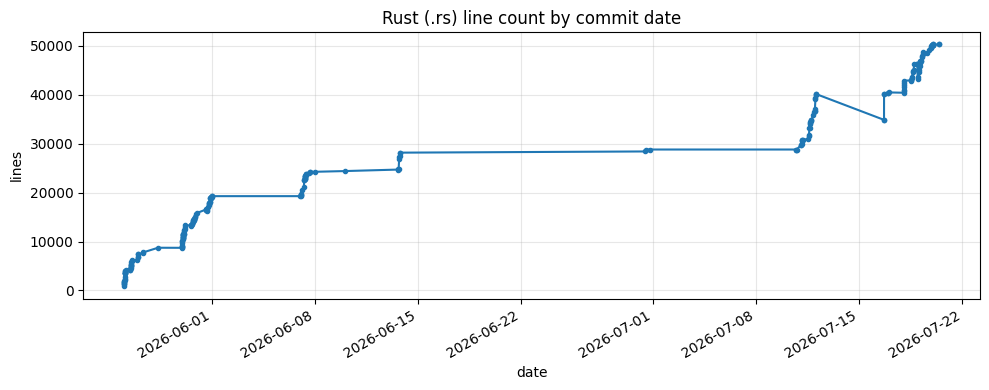

commits: 228
first: 82fd07303198  2026-05-26T00:27:17+08:00  829
last:  2a26cb036272  2026-07-20T10:33:18+08:00  50271


In [7]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while root != root.parent and not (root / "logs" / "rust-lines.json").exists():
    root = root.parent
path = root / "logs" / "rust-lines.json"

raw = json.loads(path.read_text())
rows = sorted(
    (
        datetime.fromisoformat(entry["date"]),
        entry["line"],
        commit[:12],
    )
    for commit, entry in raw.items()
    if isinstance(entry, dict) and "date" in entry and "line" in entry
)

dates = [r[0] for r in rows]
lines = [r[1] for r in rows]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, lines, marker="o", markersize=3, linewidth=1.5)
ax.set_title("Rust (.rs) line count by commit date")
ax.set_xlabel("date")
ax.set_ylabel("lines")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"commits: {len(rows)}")
if rows:
    print(f"first: {rows[0][2]}  {rows[0][0].isoformat()}  {rows[0][1]}")
    print(f"last:  {rows[-1][2]}  {rows[-1][0].isoformat()}  {rows[-1][1]}")